# Data Wrangling di Serie Temporali IoT in Agricoltura: Confronto Metodi di Interpolazione

## Executive Summary
I sensori utilizzati nell'ambito dell'agricoltura di precisione possono subire la perdita di dati per varie ragioni (guasti alla rete, eventi meteorologici intensi, scaricamento della batteria etc..). Il dataset utilizzato in questo notebook non proviene da dati reali ma mira a simulare una situazione realistica descrivendo l'umiditä del suolo durante un periodo preciso di tempo. Il dataset si presenta come completo ma vengono introdotte deliberatamente delle interruzioni per simulare la perdita durante un evento di pioggia. Attraverso l'uso di tre metodi di interpolazione diversi (lineare, spline e forward-fill), si giunge alla conclusione che tutti i metodi presentano un errore rilevante (RMSE > 7) quando isolato specificamente sul periodo di interruzione prolungata, rispetto a un RMSE aggregato più basso (~5) che include anche le micro-interruzioni più semplici. Per questo motivo nel caso di interruzioni prolungate nella trasmissione di dati non è sufficiente ricorrere all'interpolazione ma è necessario integrare fonti dati esterne.  

In [1]:
#Import & setup
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

np.random.seed(42)
sns.set_style("whitegrid")

In [2]:
#Generazione dataset pulito (ground truth)
date_range = pd.date_range(start="2025-04-01", end="2025-05-30", freq="h")
n = len(date_range)

hour_of_day = date_range.hour
temperature = 18 + 8 * np.sin((hour_of_day - 6) / 24 * 2 * np.pi) + np.random.normal(0, 1, n)

rain_prob = 0.03
rain_event = np.random.binomial(1, rain_prob, n)
rain_mm = rain_event * np.random.exponential(5, n)

soil_moisture = np.zeros(n)
soil_moisture[0] = 25

field_capacity = 45
wilting_point = 8
decay_rate = 0.015

for i in range(1, n):
    drainage = decay_rate * (soil_moisture[i-1] - wilting_point)
    saturation_factor = 1 - (soil_moisture[i-1] - wilting_point) / (field_capacity - wilting_point)
    rain_effect = rain_mm[i] * 1.5 * saturation_factor
    soil_moisture[i] = soil_moisture[i-1] - drainage + rain_effect
    soil_moisture[i] = np.clip(soil_moisture[i], wilting_point, field_capacity)

df = pd.DataFrame({
    "timestamp": date_range,
    "soil_moisture_pct": soil_moisture,
    "temperature_c": temperature,
    "rain_mm": rain_mm
})

df.head()

,timestamp,soil_moisture_pct,temperature_c,rain_mm
0,2025-04-01 00:00:00,25.000000,10.496714,0.0
1,2025-04-01 01:00:00,24.745000,10.134329,0.0
2,2025-04-01 02:00:00,24.493825,11.719485,0.0
3,2025-04-01 03:00:00,24.246418,13.866176,0.0
4,2025-04-01 04:00:00,24.002721,13.765847,0.0


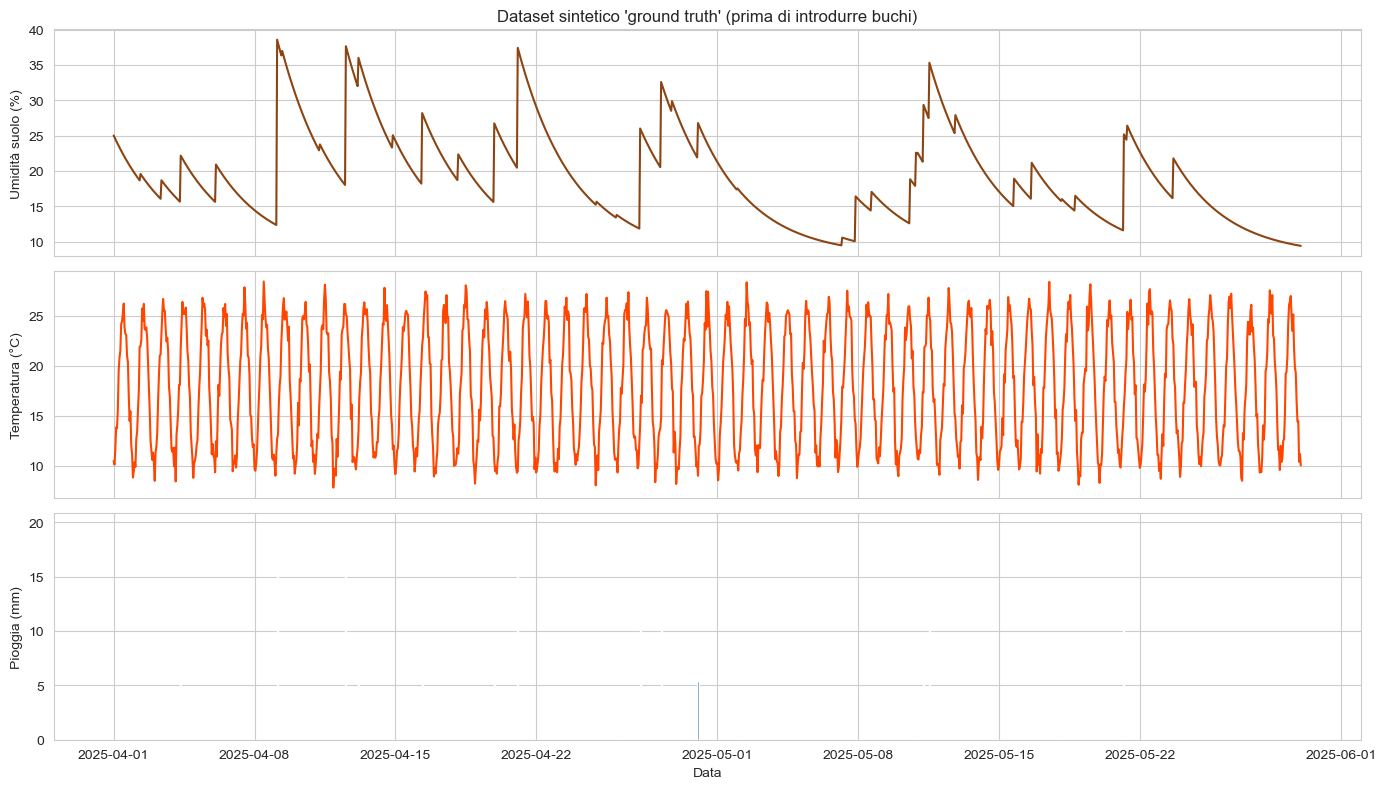

In [3]:
#Grafico ground truth
fig, axes = plt.subplots(3, 1, figsize=(14, 8), sharex=True)

axes[0].plot(df["timestamp"], df["soil_moisture_pct"], color="saddlebrown")
axes[0].set_ylabel("Umidità suolo (%)")
axes[0].set_title("Dataset sintetico 'ground truth' (prima di introdurre buchi)")

axes[1].plot(df["timestamp"], df["temperature_c"], color="orangered")
axes[1].set_ylabel("Temperatura (°C)")

axes[2].bar(df["timestamp"], df["rain_mm"], color="steelblue", width=0.05)
axes[2].set_ylabel("Pioggia (mm)")
axes[2].set_xlabel("Data")

plt.tight_layout()
plt.show()

## Simulazione di Interruzioni Realistiche

I sensori IoT in campo non perdono dati in modo puramente casuale. Introduciamo due 
tipologie di interruzione che riflettono scenari reali distinti:

- **Micro-interruzioni (1-4 ore)**: rumore di rete tipico di connessioni IoT rurali, 
  distribuite casualmente lungo la serie.
- **Blackout prolungato (72 ore)**: posizionato deliberatamente in corrispondenza di un 
  evento di pioggia intensa, per simulare lo scenario peggiore — un guasto prolungato del 
  sensore proprio quando i dati sarebbero più critici da catturare.

Manteniamo una copia del dataset originale (`df_clean`) come "ground truth" nota, 
condizione impossibile da avere con dati reali ma fondamentale per validare oggettivamente 
i metodi di imputazione che seguono.

In [4]:
#Introduzione dei buchi (micro-interruzioni + blackout)
df_clean = df.copy()
df_dirty = df.copy()

n_micro_gaps = 25
for _ in range(n_micro_gaps):
    start_idx = np.random.randint(0, n - 5)
    gap_length = np.random.randint(1, 5)
    df_dirty.loc[start_idx:start_idx + gap_length, "soil_moisture_pct"] = np.nan

peak_date = pd.Timestamp("2025-04-12")
peak_idx = df_dirty[df_dirty["timestamp"] >= peak_date].index[0]

blackout_start = peak_idx - 12
blackout_length = 72

df_dirty.loc[blackout_start:blackout_start + blackout_length, "soil_moisture_pct"] = np.nan

missing_pct = df_dirty["soil_moisture_pct"].isna().mean() * 100
print(f"Percentuale di dati mancanti: {missing_pct:.2f}%")

Percentuale di dati mancanti: 11.15%


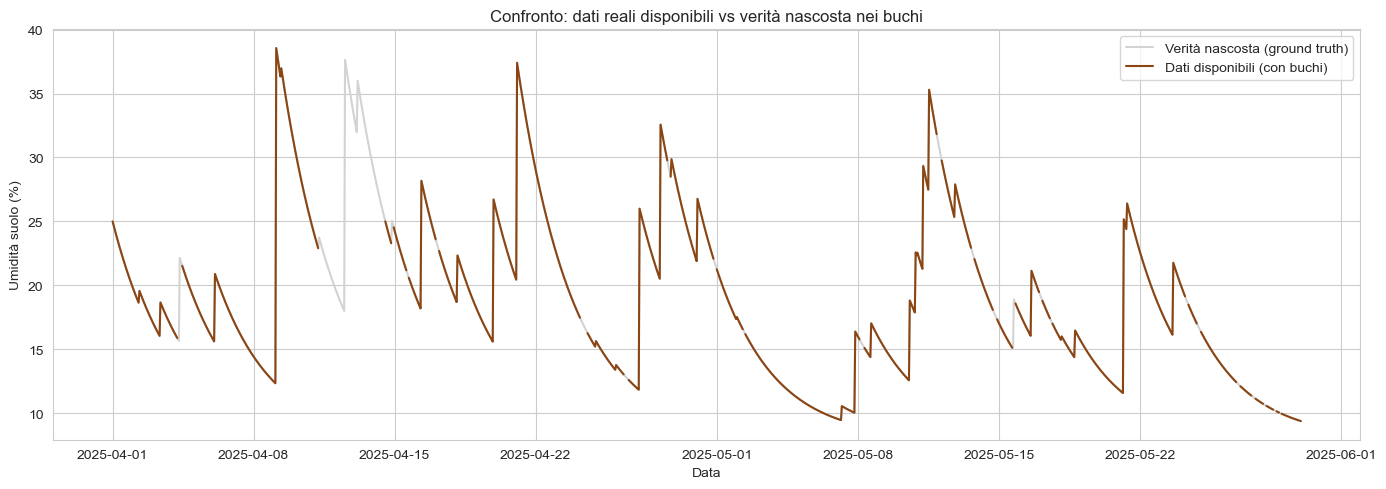

In [5]:
#Grafico confronto pulito/sporco
fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(df_clean["timestamp"], df_clean["soil_moisture_pct"], 
        color="lightgray", label="Verità nascosta (ground truth)", linewidth=1.5)
ax.plot(df_dirty["timestamp"], df_dirty["soil_moisture_pct"], 
        color="saddlebrown", label="Dati disponibili (con buchi)", linewidth=1.5)

ax.set_ylabel("Umidità suolo (%)")
ax.set_xlabel("Data")
ax.set_title("Confronto: dati reali disponibili vs verità nascosta nei buchi")
ax.legend()

plt.tight_layout()
plt.show()

## Confronto di Metodi di Interpolazione

Applichiamo tre approcci comuni per la gestione dei dati mancanti:

1. **Interpolazione lineare** — assume una transizione costante tra i due punti noti.
2. **Interpolazione spline (cubica)** — modella una curva più flessibile, ma rischia di 
   generare oscillazioni non realistiche su gap lunghi (overfitting locale).
3. **Forward-fill** — ripete l'ultimo valore osservato, ignorando qualsiasi trend.

La valutazione avviene in due fasi: prima un RMSE aggregato su tutti i punti mancanti, 
poi un RMSE isolato specificamente sul blackout di 72 ore — la metrica aggregata da sola 
rischia di mascherare quanto ciascun metodo fallisca nel caso realmente difficile.

In [6]:
#Tre metodi di interpolazione
df_interp = df_dirty.copy()
df_interp = df_interp.set_index("timestamp")

df_interp["linear"] = df_interp["soil_moisture_pct"].interpolate(method="linear")
df_interp["spline"] = df_interp["soil_moisture_pct"].interpolate(method="spline", order=3)
df_interp["ffill"] = df_interp["soil_moisture_pct"].ffill()

df_interp.head()

,soil_moisture_pct,temperature_c,rain_mm,linear,spline,ffill
timestamp,,,,,,
2025-04-01 00:00:00,25.000000,10.496714,0.0,25.000000,25.000000,25.000000
2025-04-01 01:00:00,24.745000,10.134329,0.0,24.745000,24.745000,24.745000
2025-04-01 02:00:00,24.493825,11.719485,0.0,24.493825,24.493825,24.493825
2025-04-01 03:00:00,24.246418,13.866176,0.0,24.246418,24.246418,24.246418
2025-04-01 04:00:00,24.002721,13.765847,0.0,24.002721,24.002721,24.002721


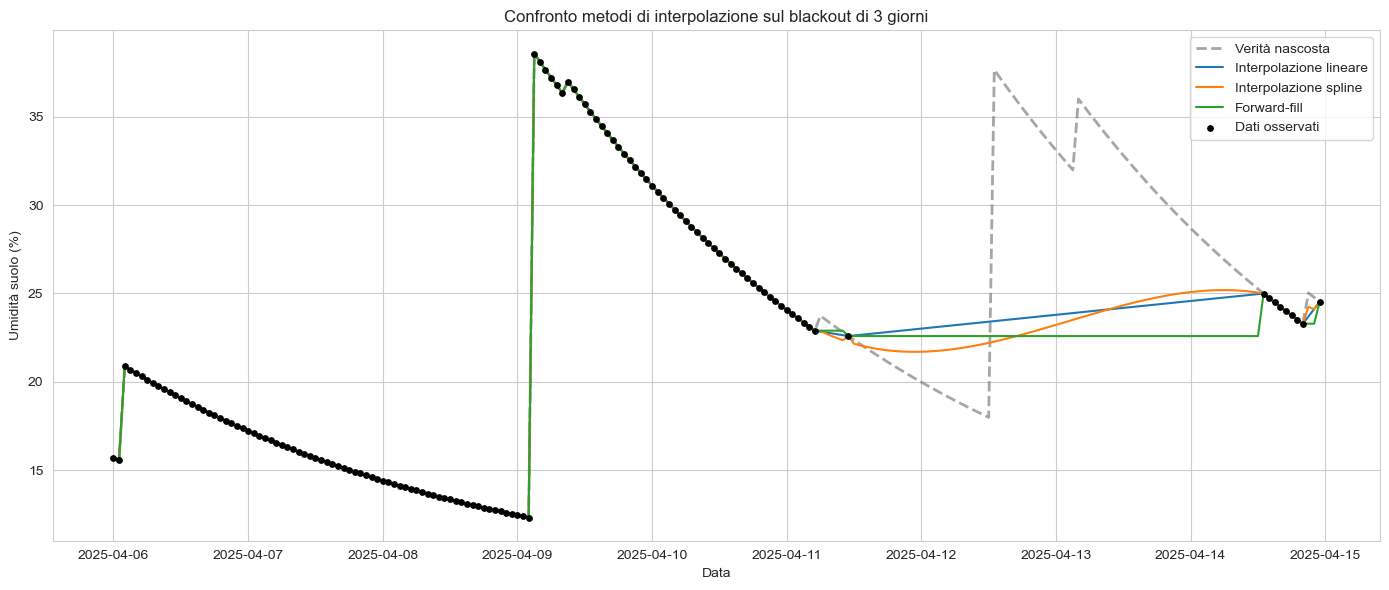

In [7]:
#Grafico zoomato confronto metodi
zoom_start = "2025-04-06"
zoom_end = "2025-04-14"

df_zoom = df_interp.loc[zoom_start:zoom_end]
df_clean_zoom = df_clean.set_index("timestamp").loc[zoom_start:zoom_end]

fig, ax = plt.subplots(figsize=(14, 6))

ax.plot(df_clean_zoom.index, df_clean_zoom["soil_moisture_pct"], 
        color="gray", linestyle="--", label="Verità nascosta", linewidth=2, alpha=0.7)
ax.plot(df_zoom.index, df_zoom["linear"], label="Interpolazione lineare", linewidth=1.5)
ax.plot(df_zoom.index, df_zoom["spline"], label="Interpolazione spline", linewidth=1.5)
ax.plot(df_zoom.index, df_zoom["ffill"], label="Forward-fill", linewidth=1.5)

observed = df_dirty.set_index("timestamp").loc[zoom_start:zoom_end]
ax.scatter(observed.dropna(subset=["soil_moisture_pct"]).index, 
           observed.dropna(subset=["soil_moisture_pct"])["soil_moisture_pct"],
           color="black", s=15, zorder=5, label="Dati osservati")

ax.set_ylabel("Umidità suolo (%)")
ax.set_xlabel("Data")
ax.set_title("Confronto metodi di interpolazione sul blackout di 3 giorni")
ax.legend()

plt.tight_layout()
plt.show()

In [8]:
#RMSE aggregato
from sklearn.metrics import mean_squared_error

mask_missing = df_dirty.set_index("timestamp")["soil_moisture_pct"].isna()
true_values = df_clean.set_index("timestamp").loc[mask_missing, "soil_moisture_pct"]

results = {}
for method in ["linear", "spline", "ffill"]:
    predicted = df_interp.loc[mask_missing, method]
    rmse = np.sqrt(mean_squared_error(true_values, predicted))
    results[method] = rmse

for method, rmse in results.items():
    print(f"{method:10s} → RMSE: {rmse:.2f}")

linear     → RMSE: 4.84
spline     → RMSE: 4.92
ffill      → RMSE: 5.55


In [9]:
#RMSE isolato sul blackout
blackout_start_time = df_dirty.loc[blackout_start, "timestamp"]
blackout_end_time = df_dirty.loc[blackout_start + blackout_length, "timestamp"]

mask_blackout_only = (
    (df_dirty.set_index("timestamp").index >= blackout_start_time) &
    (df_dirty.set_index("timestamp").index <= blackout_end_time)
)

true_values_blackout = df_clean.set_index("timestamp").loc[mask_blackout_only, "soil_moisture_pct"]

results_blackout = {}
for method in ["linear", "spline", "ffill"]:
    predicted = df_interp.loc[mask_blackout_only, method]
    rmse = np.sqrt(mean_squared_error(true_values_blackout, predicted))
    results_blackout[method] = rmse

print("RMSE solo sul blackout di 3 giorni:")
for method, rmse in results_blackout.items():
    print(f"{method:10s} → RMSE: {rmse:.2f}")

RMSE solo sul blackout di 3 giorni:
linear     → RMSE: 7.08
spline     → RMSE: 7.16
ffill      → RMSE: 8.03


## Conclusioni e Limiti

Il confronto quantitativo conferma l'osservazione qualitativa iniziale: **forward-fill è 
il metodo meno affidabile** su interruzioni lunghe (RMSE 8.03 sul blackout), mentre 
lineare e spline ottengono risultati simili tra loro (7.08 e 7.16 rispettivamente) — 
smentendo l'ipotesi iniziale che la spline, essendo più "flessibile", avrebbe recuperato 
meglio la dinamica dell'evento nascosto.

**Limite fondamentale**: nessuno dei tre metodi supera un RMSE di 7 sul blackout di 72 ore, 
che nascondeva in realtà due eventi di pioggia consecutivi. Questo dimostra che 
l'interpolazione basata unicamente sulla serie storica del sensore ha un tetto di 
affidabilità intrinseco quando l'evento mancante è complesso e prolungato.

**Direzioni future**: l'integrazione di fonti dati esterne — stazioni meteorologiche 
pubbliche, sensori ridondanti nello stesso appezzamento, o dati satellitari di 
precipitazione (es. CHIRPS) — rappresenta l'approccio più robusto per la gestione di 
interruzioni prolungate in scenari IoT agricoli reali, superando il limite intrinseco 
dei metodi di imputazione univariata.